# Preprocessing the wine quality dataset to understand the features are more important for modeling.

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif, f_regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestClassifier



df = pd.read_csv('winequality-red.csv', delimiter=';')

df.info()
df.dropna(inplace=True)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1598 non-null   float64
 1   volatile acidity      1598 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1598 non-null   float64
 4   chlorides             1598 non-null   float64
 5   free sulfur dioxide   1598 non-null   float64
 6   total sulfur dioxide  1598 non-null   float64
 7   density               1598 non-null   float64
 8   pH                    1598 non-null   float64
 9   sulphates             1598 non-null   float64
 10  alcohol               1598 non-null   float64
 11  quality               1598 non-null   float64
dtypes: float64(12)
memory usage: 150.0 KB


In [38]:
imputer = KNNImputer(n_neighbors=2)
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
df_numerical = df[numerical_cols]
df_imputed = imputer.fit_transform(df_numerical)
df_imputed

'''

'''
# imputer = KNNImputer(n_neighbors=2)
# df_imputed = imputer.fit_transform(df)
# df_imputed = pd.DataFrame(df_imputed, columns=df.columns)
# df_imputed.isnull().sum()
# df_imputed.to_csv("winequality-red-imputed.csv", index=False)

'\n\n'

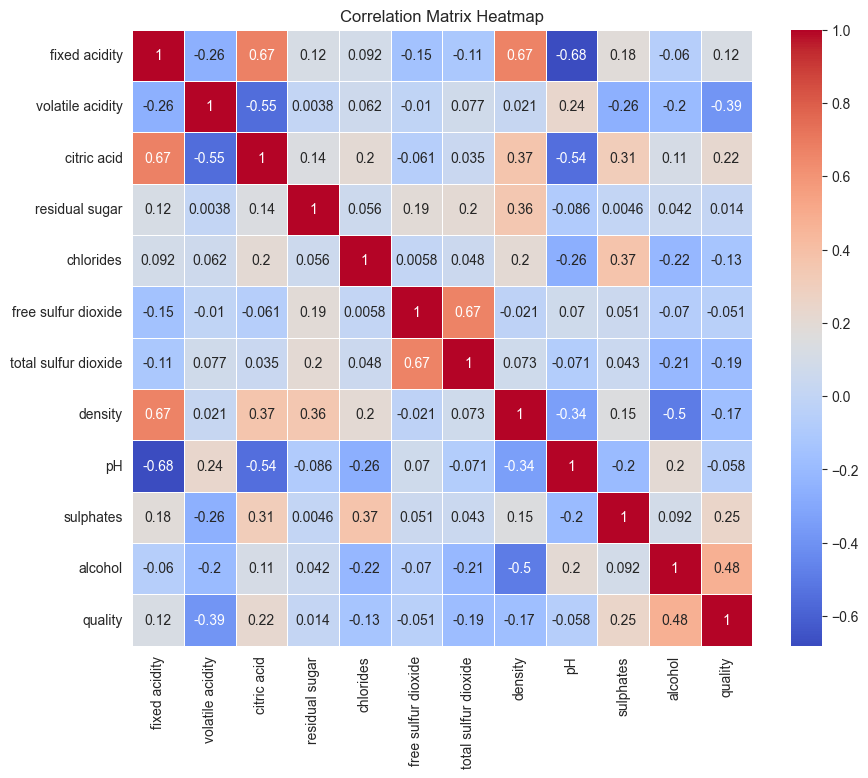

In [39]:
# Correlation 

'''
   Here We check the relationship between all features and the target feature (Quality)
   And from the plot we can notice that quality has a moderate relations with 



'''
correlation_matrix = df.corr()

# Create a heatmap for the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Matrix Heatmap")
plt.show()

#### This code performs feature selection using SelectKBest with ANOVA F-values (f_classif) to select the top 3 most important features.
#### It then trains a RandomForestClassifier on these selected features and evaluates its performance using the Mean Squared Error (MSE). 
#### Finally, it prints out the names of the features that were selected.

In [40]:
# Define features (X) and target (y)
X = df.drop(columns=['quality'])  # Features: All columns except 'quality'
y = df['quality']                 # Target: 'quality'

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Use SelectKBest to select top 5 features based on f_regression
selector = SelectKBest(score_func=f_classif, k=3)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

# Train a RandomForestClassifier on the selected features
model = RandomForestClassifier(random_state=42)
model.fit(X_train_selected, y_train)

# Predict and evaluate performance using Mean Squared Error (MSE)
y_pred = model.predict(X_test_selected)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error with selected features: {mse:.4f}")

# Get the selected feature names
selected_features = X.columns[selector.get_support()]
print("\nSelected Features classification:\n", selected_features)

Mean Squared Error with selected features: 0.4717

Selected Features classification:
 Index(['volatile acidity', 'total sulfur dioxide', 'alcohol'], dtype='object')


In [41]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Use SelectKBest to select top 5 features based on f_regression
selector = SelectKBest(score_func=f_regression, k=3)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

# Train a RandomForestRegressor on the selected features
model = RandomForestRegressor(random_state=42)
model.fit(X_train_selected, y_train)

# Predict and evaluate performance using Mean Squared Error (MSE)
y_pred = model.predict(X_test_selected)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error with selected features: {mse:.4f}")

# Get the selected feature names
selected_features = X.columns[selector.get_support()]
print("\nSelected Features regression:\n", selected_features)

Mean Squared Error with selected features: 0.3757

Selected Features regression:
 Index(['volatile acidity', 'sulphates', 'alcohol'], dtype='object')


## Performing PCA on the redWine dataset

### To identify the best features that explain the most variance in the dataset, I analyzed the feature loadings for the top few principal components (PCs) that capture the highest explained variance. Based on the loadings for the first three principal components, which together account for approximately 59.74% of the total variance, the most significant features are **fixed acidity**, **citric acid**, **density**, **pH**, **free sulfur dioxide**, **total sulfur dioxide**, **alcohol**, and **volatile acidity**. These features were selected because they exhibit the highest loadings (positive or negative) across the first three PCs, indicating their strong contribution to the overall variance in the data. Choosing these features allows us to retain the most critical information while simplifying the model, making it suitable for further analysis or predictive modeling.

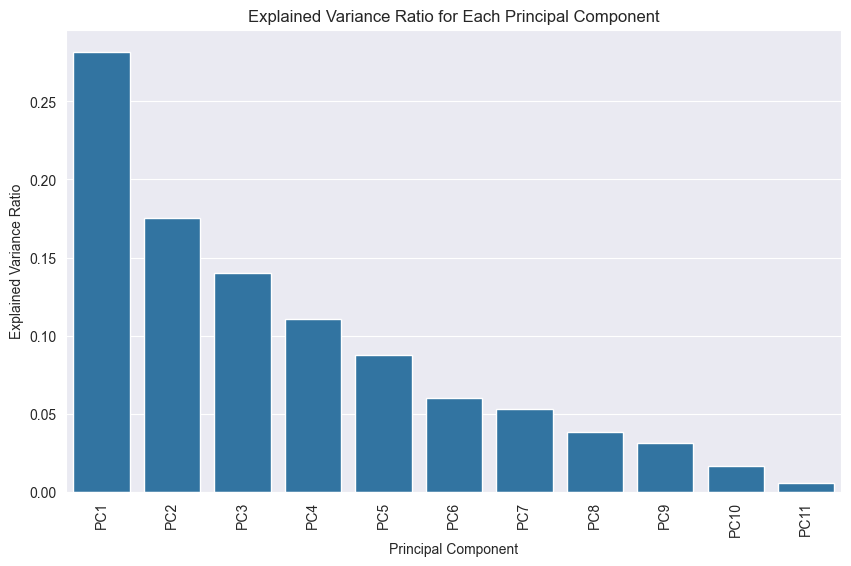


Feature Loadings onto Principal Components:
                           PC1       PC2       PC3       PC4       PC5  \
fixed acidity         0.489259 -0.111130 -0.122611 -0.229792 -0.082347   
volatile acidity     -0.238496  0.276368 -0.449824  0.078119  0.216979   
citric acid           0.464286 -0.153186  0.235258 -0.078235 -0.058151   
residual sugar        0.146256  0.269446  0.097046 -0.373249  0.732834   
chlorides             0.211566  0.148786 -0.093633  0.665525  0.246432   
free sulfur dioxide  -0.035116  0.512548  0.432806 -0.045766 -0.153356   
total sulfur dioxide  0.025592  0.569369  0.323730 -0.035257 -0.221181   
density               0.395444  0.232804 -0.339989 -0.174528  0.155939   
pH                   -0.438374  0.006483  0.054524 -0.004464  0.267100   
sulphates             0.242381 -0.038133  0.278896  0.551207  0.228677   
alcohol              -0.113348 -0.387926  0.469706 -0.122831  0.352976   

                           PC6       PC7       PC8       PC9      

In [45]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns


# separating out the features and the target variable (quality)
features = df.columns[:-1]  # adding columns except 'quality'
x = df.loc[:, features].values
y = df.loc[:, ['quality']].values  # target variable (quality)

# standardizing the features
x = StandardScaler().fit_transform(x)

# applying PCA to retain all components
pca = PCA(n_components=len(features))  # using all features
principal_components = pca.fit_transform(x)

# explained variance ratio for each principal component
explained_variance_ratio = pca.explained_variance_ratio_

# create a DataFrame to store the explained variance ratio for each component
explained_variance_df = pd.DataFrame({
    'Principal Component': [f'PC{i+1}' for i in range(len(features))],
    'Explained Variance Ratio': explained_variance_ratio
})

plt.figure(figsize=(10, 6))
sns.barplot(x='Principal Component', y='Explained Variance Ratio', data=explained_variance_df)

plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance Ratio for Each Principal Component')

plt.xticks(rotation=90)  # Rotate the labels for better readability
plt.show()

loadings = pd.DataFrame(pca.components_.T, columns=[f'PC{i+1}' for i in range(len(features))], index=features)
print("\nFeature Loadings onto Principal Components:")
print(loadings)
